# Sentiment Analysis - CNN Model

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Embedding, Lambda, Conv1D, MaxPooling1D, GlobalMaxPooling1D, Dense, Dropout, Input, BatchNormalization, Concatenate, Add, Activation, GlobalAveragePooling1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from nltk.stem import WordNetLemmatizer

In [2]:
import os
import sys

src_path = os.path.abspath('../src')
sys.path.append(src_path)

from preprocessing.data_utils import DataUtils
from models import train_cnn

In [3]:
# due to error with allocating GPU memory, the CPU will be used
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

In [4]:
models_output_dir = '../outputs/models/cnn'

In [5]:
import fasttext
import fasttext.util

# define the model file path
model_path = "../data/embeddings/cc.en.300.bin"

# download the FastText model if it does not exist
if not os.path.exists(model_path):
    fasttext.util.download_model('en', if_exists='ignore')  # download English FastText model (300D)

# load the FastText model
fasttext_model = fasttext.load_model(model_path)

In [6]:
# preprocess and tokenize data
def preprocess_data(df, max_length=128, vocab_size=10000):
    # initialize tokenizer and lemmatizer
    tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
    lemmatizer = WordNetLemmatizer()

    # remove missing or empty values
    df = df.dropna(subset=['Review']).copy()
    df = df[df['Review'].str.strip() != '']

    # extract texts and labels
    texts = df['Review'].astype(str).tolist()
    labels = df['Polarity'].values

    # apply lemmatization
    texts = [" ".join([lemmatizer.lemmatize(word) for word in text.split()]) for text in texts]

    # tokenize and pad sequences
    tokenizer.fit_on_texts(texts)
    sequences = tokenizer.texts_to_sequences(texts)
    padded_sequences = pad_sequences(sequences, maxlen=max_length, padding='post', truncating='post')

    return padded_sequences, np.array(labels), tokenizer

In [7]:
# preprocess and tokenize data using existing tokenizer
def tokenize_with_existing_tokenizer(df, tokenizer, max_length):
    texts = df['Review'].astype(str).tolist()
    sequences = tokenizer.texts_to_sequences(texts)
    padded_sequences = pad_sequences(sequences, maxlen=max_length, padding='post', truncating='post')
    labels = df['Polarity'].values
    return padded_sequences, labels

# 1. CNN Model - Amazon Books Reviews

## 1.1. Loading Data

In [8]:
# load the dataset
amazon_file = '../data/preprocessed/amazon.csv'
amazon_df = pd.read_csv(amazon_file, engine='python', encoding="ISO-8859-1")

In [9]:
# preview the data
amazon_df.head()

,Polarity,Review
0,0,As a Man Stinketh
1,1,MY FAVORITE!!
2,1,Epic novel
3,1,Very good source for Web Applications Development
4,1,Great fantasy


In [10]:
train_val_amazon_df, test_amazon_df = train_test_split(
    amazon_df, 
    test_size=0.15, 
    random_state=42, 
    stratify=amazon_df['Polarity']
)

In [11]:
train_amazon_df, val_amazon_df = train_test_split(
    train_val_amazon_df, 
    test_size=0.1765, # 15% of the original data
    random_state=42, 
    stratify=train_val_amazon_df['Polarity']
)

In [12]:
DataUtils.count_reviews_by_polarity(train_amazon_df)

Number of reviews with Polarity=1: 49382
Number of reviews with Polarity=0: 49382


In [13]:
DataUtils.count_reviews_by_polarity(val_amazon_df)

Number of reviews with Polarity=1: 10585
Number of reviews with Polarity=0: 10584


In [14]:
DataUtils.count_reviews_by_polarity(test_amazon_df)

Number of reviews with Polarity=1: 10582
Number of reviews with Polarity=0: 10583


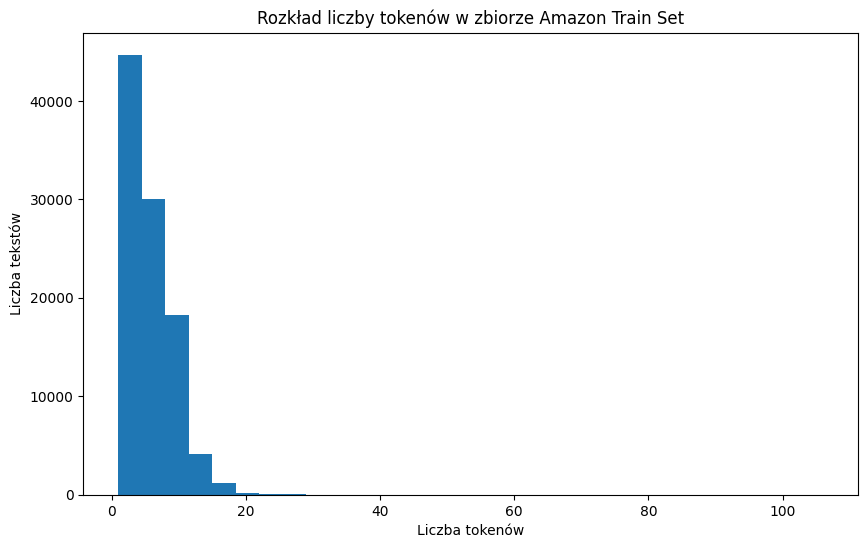

In [15]:
DataUtils.plot_token_distribution(train_amazon_df, "Amazon Train Set")

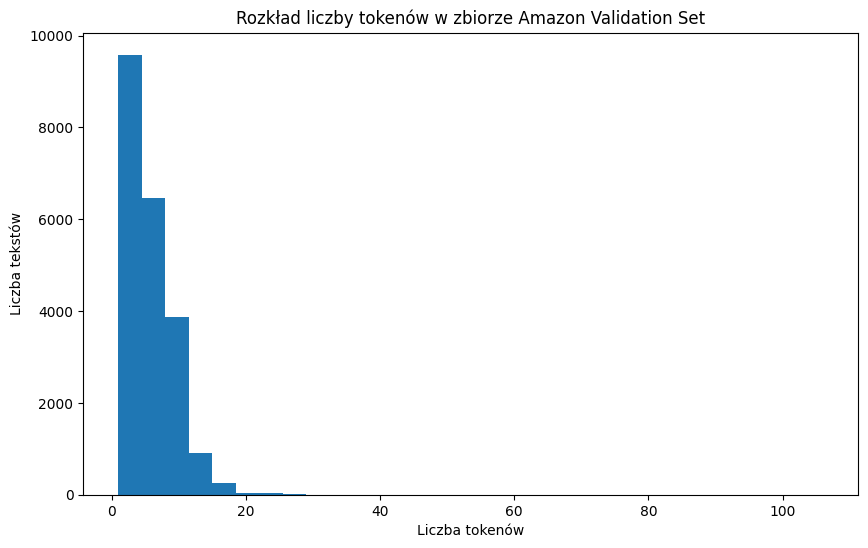

In [16]:
DataUtils.plot_token_distribution(val_amazon_df, "Amazon Validation Set")

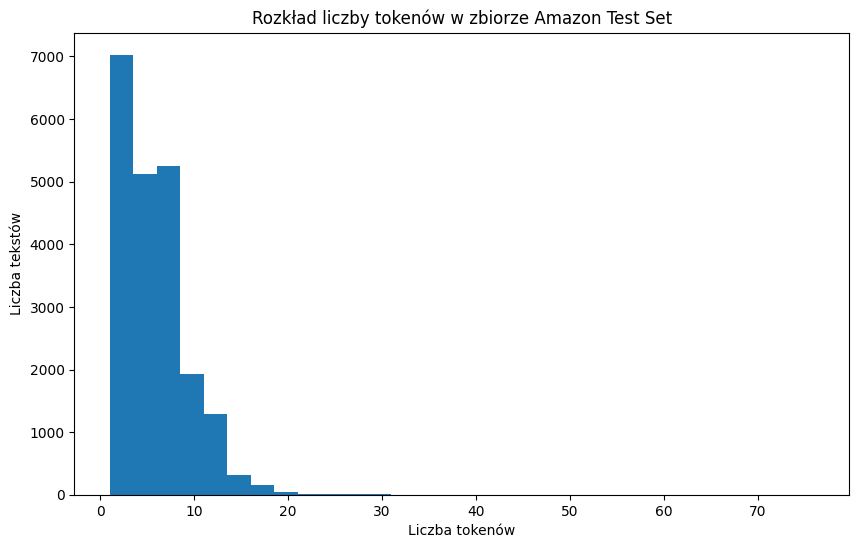

In [17]:
DataUtils.plot_token_distribution(test_amazon_df, "Amazon Test Set")

## 1.2. Data Preprocessing

In [18]:
# set preprocessing parameters
vocab_size = 12000  # maximum number of words in the tokenizer
max_length = 32  # maximum length of input sequences

In [19]:
# preprocess train data and fit tokenizer
X_train, y_train, tokenizer = preprocess_data(train_amazon_df, max_length=max_length, vocab_size=vocab_size)

In [20]:
# preprocess val data 
X_val, y_val = tokenize_with_existing_tokenizer(val_amazon_df, tokenizer, max_length)

In [21]:
# preprocess test data
X_test, y_test = tokenize_with_existing_tokenizer(test_amazon_df, tokenizer, max_length)

## 1.3. Model Training

In [22]:
# set model parameters
batch_size = 32
epochs = 10
learning_rate = 0.001

In [23]:
# set embedding parameters
embedding_dim = 300  # dimension of word vectors
embedding_matrix = np.zeros((vocab_size, embedding_dim)) 

for word, i in tokenizer.word_index.items():
    if i < vocab_size:  
        embedding_matrix[i] = fasttext_model.get_word_vector(word)  

print("Embedding matrix created with shape:", embedding_matrix.shape)

Embedding matrix created with shape: (12000, 300)


In [24]:
# define model architecture
model_cnn = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, 
              input_length=max_length, weights=[embedding_matrix], 
              trainable=False),
    Conv1D(filters=128, kernel_size=2, activation='relu'),
    GlobalMaxPooling1D(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

In [25]:
model_cnn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [26]:
model_cnn.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 32, 300)           3600000   
                                                                 
 conv1d (Conv1D)             (None, 31, 128)           76928     
                                                                 
 global_max_pooling1d (Globa  (None, 128)              0         
 lMaxPooling1D)                                                  
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense (Dense)               (None, 32)                4128      
                                                                 
 dropout_1 (Dropout)         (None, 32)                0         
                                                        

In [27]:
# define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [28]:
# train the model
history_cnn = model_cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping]
)

Epoch 1/10
3087/3087 [==============================] - 15s 5ms/step - loss: 0.4314 - accuracy: 0.7948 - val_loss: 0.3905 - val_accuracy: 0.8124
Epoch 2/10
3087/3087 [==============================] - 15s 5ms/step - loss: 0.3827 - accuracy: 0.8205 - val_loss: 0.3757 - val_accuracy: 0.8268
Epoch 3/10
3087/3087 [==============================] - 14s 5ms/step - loss: 0.3654 - accuracy: 0.8296 - val_loss: 0.3681 - val_accuracy: 0.8304
Epoch 4/10
3087/3087 [==============================] - 14s 5ms/step - loss: 0.3534 - accuracy: 0.8360 - val_loss: 0.3693 - val_accuracy: 0.8277
Epoch 5/10
3087/3087 [==============================] - 14s 5ms/step - loss: 0.3424 - accuracy: 0.8420 - val_loss: 0.3602 - val_accuracy: 0.8348
Epoch 6/10
3087/3087 [==============================] - 14s 5ms/step - loss: 0.3358 - accuracy: 0.8461 - val_loss: 0.3599 - val_accuracy: 0.8351
Epoch 7/10
3087/3087 [==============================] - 14s 5ms/step - loss: 0.3270 - accuracy: 0.8518 - val_loss: 0.3615 - val_ac

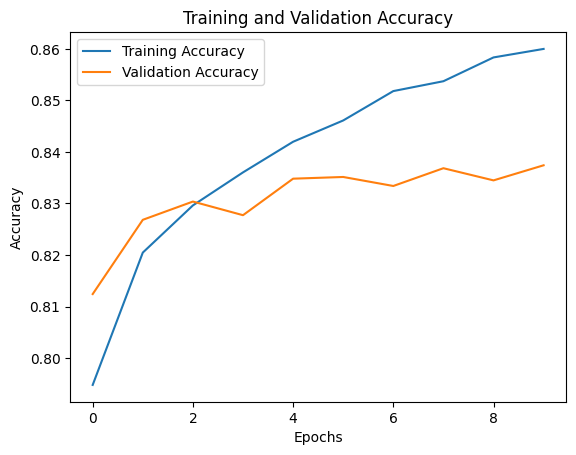

In [29]:
# plot accuracy on training and validation data
plt.plot(history_cnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

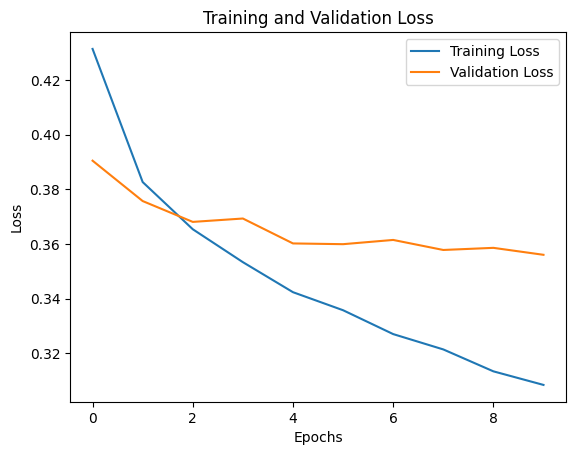

In [30]:
# plot loss on training and validation data
plt.plot(history_cnn.history['loss'], label='Training Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [31]:
# evaluate the model on the validation set
print("\nValidation Results:")
y_val_pred = (model_cnn.predict(X_val) > 0.5).astype(int).flatten()
print(classification_report(y_val, y_val_pred))


Validation Results:
662/662 [==============================] - 1s 2ms/step
              precision    recall  f1-score   support

           0       0.84      0.83      0.84     10584
           1       0.84      0.84      0.84     10585

    accuracy                           0.84     21169
   macro avg       0.84      0.84      0.84     21169
weighted avg       0.84      0.84      0.84     21169



## 1.4. Searching for Best Model Parameters

### 1.4.1. BiCNN

In [32]:
def bicnn_amazon(vocab_size, learning_rate, embedding_dim, embedding_matrix):
    inputs = Input(shape=(32,))

    embedding = Embedding(input_dim=vocab_size, output_dim=embedding_dim, 
                          input_length=32, weights=[embedding_matrix], 
                          trainable=False)(inputs)

    # forward CNN (left-to-right processing)
    conv_fw = Conv1D(filters=128, kernel_size=3, activation='relu', padding='same')(embedding)
    conv_fw = BatchNormalization()(conv_fw)  
    pool_fw1 = GlobalMaxPooling1D()(conv_fw) 
    pool_fw2 = GlobalAveragePooling1D()(conv_fw) 

    # backward CNN (right-to-left processing)
    reversed_embedding = Lambda(lambda x: tf.reverse(x, axis=[1]))(embedding)  # reverse embeddings 
    conv_bw = Conv1D(filters=128, kernel_size=3, activation='relu', padding='same')(reversed_embedding)
    conv_bw = BatchNormalization()(conv_bw)
    pool_bw1 = GlobalMaxPooling1D()(conv_bw)
    pool_bw2 = GlobalAveragePooling1D()(conv_bw)

    # concatenation of forward and backward features
    concat = Concatenate()([pool_fw1, pool_fw2, pool_bw1, pool_bw2])
    dropout = Dropout(0.5)(concat) 

    # fully connected layer for classification
    dense = Dense(256, activation='relu')(dropout)
    output = Dense(1, activation='sigmoid')(dense)

    model = Model(inputs=inputs, outputs=output)

    model.compile(loss='binary_crossentropy', optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), metrics=['accuracy'])
    
    return model


In [33]:
model_bicnn = bicnn_amazon(vocab_size=vocab_size, learning_rate=learning_rate, embedding_dim=embedding_dim, embedding_matrix=embedding_matrix)

In [34]:
model_bicnn.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 32)]         0           []                               
                                                                                                  
 embedding_1 (Embedding)        (None, 32, 300)      3600000     ['input_1[0][0]']                
                                                                                                  
 lambda (Lambda)                (None, 32, 300)      0           ['embedding_1[0][0]']            
                                                                                                  
 conv1d_1 (Conv1D)              (None, 32, 128)      115328      ['embedding_1[0][0]']            
                                                                                              

In [35]:
# train the model
history_bicnn = model_bicnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping]
)

Epoch 1/10
3087/3087 [==============================] - 38s 12ms/step - loss: 0.4606 - accuracy: 0.7791 - val_loss: 0.4390 - val_accuracy: 0.7915
Epoch 2/10
3087/3087 [==============================] - 36s 12ms/step - loss: 0.3959 - accuracy: 0.8113 - val_loss: 0.3883 - val_accuracy: 0.8209
Epoch 3/10
3087/3087 [==============================] - 35s 11ms/step - loss: 0.3772 - accuracy: 0.8221 - val_loss: 0.3798 - val_accuracy: 0.8237
Epoch 4/10
3087/3087 [==============================] - 36s 12ms/step - loss: 0.3655 - accuracy: 0.8280 - val_loss: 0.3670 - val_accuracy: 0.8266
Epoch 5/10
3087/3087 [==============================] - 34s 11ms/step - loss: 0.3524 - accuracy: 0.8354 - val_loss: 0.3596 - val_accuracy: 0.8322
Epoch 6/10
3087/3087 [==============================] - 34s 11ms/step - loss: 0.3441 - accuracy: 0.8391 - val_loss: 0.3633 - val_accuracy: 0.8312
Epoch 7/10
3087/3087 [==============================] - 34s 11ms/step - loss: 0.3333 - accuracy: 0.8458 - val_loss: 0.3595 -

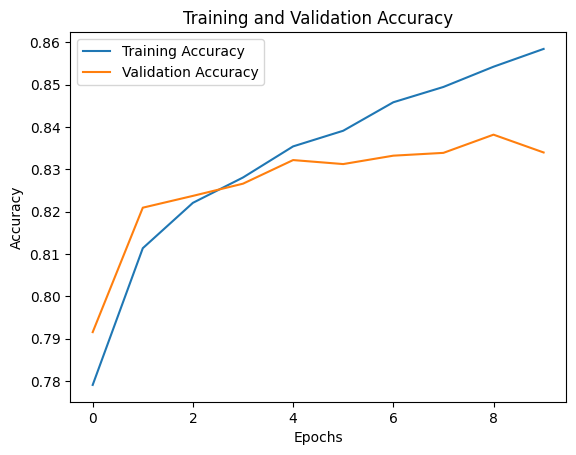

In [36]:
# plot accuracy on training and validation data
plt.plot(history_bicnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_bicnn.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

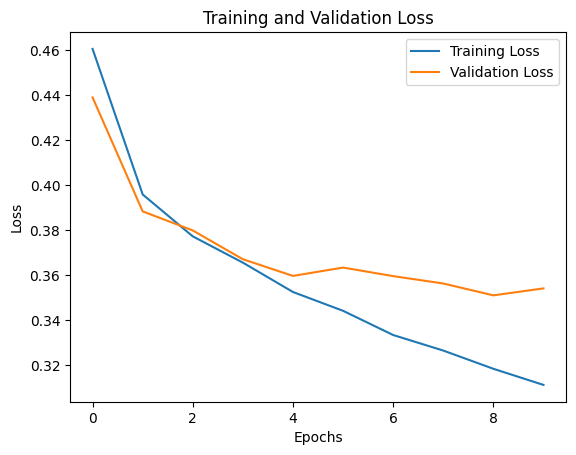

In [37]:
# plot loss on training and validation data
plt.plot(history_bicnn.history['loss'], label='Training Loss')
plt.plot(history_bicnn.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [38]:
# evaluate the model on the validation set
print("\nValidation Results:")
y_val_pred = (model_bicnn.predict(X_val) > 0.5).astype(int).flatten()
print(classification_report(y_val, y_val_pred))


Validation Results:
662/662 [==============================] - 3s 4ms/step
              precision    recall  f1-score   support

           0       0.83      0.84      0.83     10584
           1       0.84      0.83      0.83     10585

    accuracy                           0.83     21169
   macro avg       0.83      0.83      0.83     21169
weighted avg       0.83      0.83      0.83     21169



### 1.4.2. TCN (Temporal Convolutional Network) 

In [39]:
def tcn_model_amazon(vocab_size, embedding_dim, embedding_matrix, learning_rate, dilation_rates=[1, 2, 4, 8]):
    inputs = Input(shape=(32,))
    
    embedding = Embedding(input_dim=vocab_size, output_dim=embedding_dim, 
                          input_length=32, weights=[embedding_matrix], 
                          trainable=False)(inputs)

    x = embedding  # initialize feature extraction pipeline
    
    # multiple dilated convolutional layers
    for rate in dilation_rates:
        residual = x
        x = Conv1D(filters=embedding_dim, kernel_size=3, activation='relu', padding='same', dilation_rate=rate)(x)
        x = BatchNormalization()(x)
        x = Dropout(0.3)(x)
        x = Add()([x, residual])
        x = Activation('relu')(x)

    pool = GlobalMaxPooling1D()(x)

    dense = Dense(128, activation='relu')(pool)

    output = Dense(1, activation='sigmoid')(dense)

    model = Model(inputs=inputs, outputs=output)
    model.compile(loss='binary_crossentropy', optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), metrics=['accuracy'])

    return model

In [40]:
model_tcn = tcn_model_amazon(vocab_size=vocab_size, learning_rate=learning_rate, embedding_dim=embedding_dim, embedding_matrix=embedding_matrix)

In [41]:
model_tcn.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 32)]         0           []                               
                                                                                                  
 embedding_2 (Embedding)        (None, 32, 300)      3600000     ['input_2[0][0]']                
                                                                                                  
 conv1d_3 (Conv1D)              (None, 32, 300)      270300      ['embedding_2[0][0]']            
                                                                                                  
 batch_normalization_2 (BatchNo  (None, 32, 300)     1200        ['conv1d_3[0][0]']               
 rmalization)                                                                               

In [42]:
# train the model
history_tcn = model_tcn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping]
)

Epoch 1/10
3087/3087 [==============================] - 215s 69ms/step - loss: 0.5267 - accuracy: 0.7674 - val_loss: 0.4052 - val_accuracy: 0.8110
Epoch 2/10
3087/3087 [==============================] - 202s 65ms/step - loss: 0.3936 - accuracy: 0.8138 - val_loss: 0.3954 - val_accuracy: 0.8201
Epoch 3/10
3087/3087 [==============================] - 200s 65ms/step - loss: 0.3734 - accuracy: 0.8252 - val_loss: 0.3724 - val_accuracy: 0.8286
Epoch 4/10
3087/3087 [==============================] - 198s 64ms/step - loss: 0.3550 - accuracy: 0.8350 - val_loss: 0.3740 - val_accuracy: 0.8243
Epoch 5/10
3087/3087 [==============================] - 195s 63ms/step - loss: 0.3377 - accuracy: 0.8448 - val_loss: 0.3596 - val_accuracy: 0.8333
Epoch 6/10
3087/3087 [==============================] - 197s 64ms/step - loss: 0.3216 - accuracy: 0.8528 - val_loss: 0.3565 - val_accuracy: 0.8338
Epoch 7/10
3087/3087 [==============================] - 202s 65ms/step - loss: 0.3076 - accuracy: 0.8613 - val_loss: 0

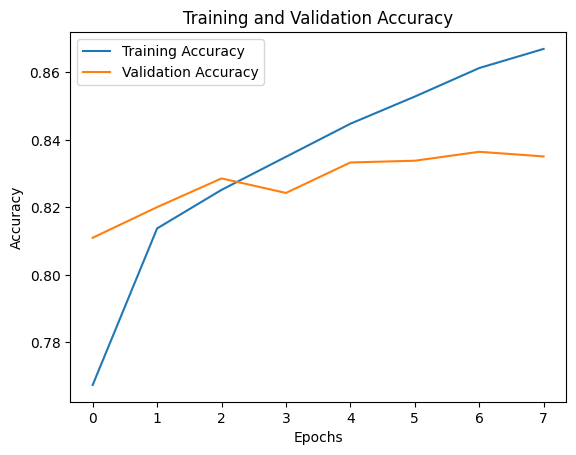

In [43]:
# plot accuracy on training and validation data
plt.plot(history_tcn.history['accuracy'], label='Training Accuracy')
plt.plot(history_tcn.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

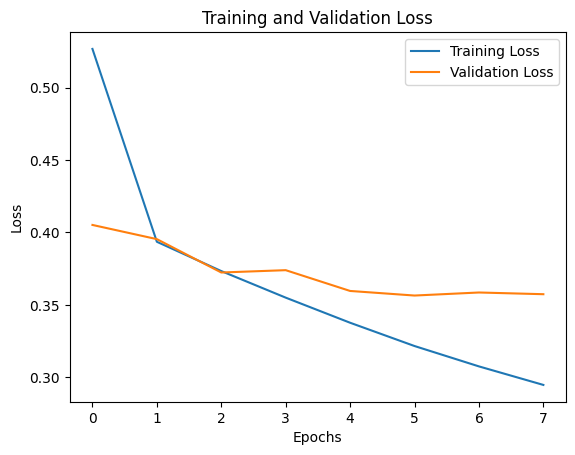

In [44]:
# plot loss on training and validation data
plt.plot(history_tcn.history['loss'], label='Training Loss')
plt.plot(history_tcn.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [45]:
# evaluate the model on the validation set
print("\nValidation Results:")
y_val_pred = (model_tcn.predict(X_val) > 0.5).astype(int).flatten()
print(classification_report(y_val, y_val_pred))


Validation Results:
662/662 [==============================] - 10s 15ms/step
              precision    recall  f1-score   support

           0       0.86      0.80      0.83     10584
           1       0.81      0.87      0.84     10585

    accuracy                           0.83     21169
   macro avg       0.84      0.83      0.83     21169
weighted avg       0.84      0.83      0.83     21169



## 1.5. Model Evaluation on Test Data

In [46]:
train_cnn.evaluate_model(model=model_cnn, tokenizer=tokenizer, test_df=test_amazon_df, max_length=max_length)

662/662 [==============================] - 1s 2ms/step

Classification Report for Test Set:

              precision    recall  f1-score   support

           0       0.84      0.84      0.84     10583
           1       0.84      0.84      0.84     10582

    accuracy                           0.84     21165
   macro avg       0.84      0.84      0.84     21165
weighted avg       0.84      0.84      0.84     21165



## 1.6. Model Evaluation on Augmented Data

In [47]:
# load the augmented test sets
test_amazon_char_swap_file = '../data/preprocessed/amazon_test_char_swap.csv'
test_amazon_char_swap_df = pd.read_csv(test_amazon_char_swap_file, engine='python', encoding="ISO-8859-1")

test_amazon_embedding_file = '../data/preprocessed/amazon_test_embedding.csv'
test_amazon_embedding_df = pd.read_csv(test_amazon_embedding_file, engine='python', encoding="ISO-8859-1")

test_amazon_eda_file = '../data/preprocessed/amazon_test_eda.csv'
test_amazon_eda_df = pd.read_csv(test_amazon_eda_file, engine='python', encoding="ISO-8859-1")

In [48]:
train_cnn.evaluate_model(model=model_cnn, tokenizer=tokenizer, test_df=test_amazon_char_swap_df, max_length=max_length)

662/662 [==============================] - 1s 2ms/step

Classification Report for Test Set:

              precision    recall  f1-score   support

           0       0.73      0.79      0.76     10583
           1       0.77      0.71      0.74     10582

    accuracy                           0.75     21165
   macro avg       0.75      0.75      0.75     21165
weighted avg       0.75      0.75      0.75     21165



In [49]:
train_cnn.evaluate_model(model=model_cnn, tokenizer=tokenizer, test_df=test_amazon_embedding_df, max_length=max_length)


662/662 [==============================] - 1s 2ms/step

Classification Report for Test Set:

              precision    recall  f1-score   support

           0       0.78      0.80      0.79     10583
           1       0.79      0.78      0.78     10582

    accuracy                           0.79     21165
   macro avg       0.79      0.79      0.79     21165
weighted avg       0.79      0.79      0.79     21165



In [50]:
train_cnn.evaluate_model(model=model_cnn, tokenizer=tokenizer, test_df=test_amazon_eda_df, max_length=max_length)


662/662 [==============================] - 1s 2ms/step

Classification Report for Test Set:

              precision    recall  f1-score   support

           0       0.80      0.80      0.80     10583
           1       0.80      0.80      0.80     10582

    accuracy                           0.80     21165
   macro avg       0.80      0.80      0.80     21165
weighted avg       0.80      0.80      0.80     21165



## 1.7. Save Model

In [51]:
model_path = os.path.join(models_output_dir, "amazon_cnn_model.keras")
model_cnn.save(model_path)

# 2. CNN Model - Sentiment140

## 2.1. Loading Data

In [52]:
# load the dataset
sentiment140_file = '../data/preprocessed/sentiment140.csv'
sentiment140_df = pd.read_csv(sentiment140_file, engine='python', encoding="ISO-8859-1")

In [53]:
# preview the data
sentiment140_df.head()

,Polarity,Review
0,1,@Alicia_86 srry u get my tweet?
1,1,@jchiarelli TTS to take text Tweets to the pho...
2,1,Mmmm apple cinnomin oatmeal
3,1,@willwallaceii thanks man. the truth can be fu...
4,1,RAIN The plants and trees are happy ^~^


In [54]:
train_val_sentiment140_df, test_sentiment140_df = train_test_split(
    sentiment140_df, 
    test_size=0.15, 
    random_state=42, 
    stratify=sentiment140_df['Polarity']
)

In [55]:
train_sentiment140_df, val_sentiment140_df = train_test_split(
    train_val_sentiment140_df, 
    test_size=0.1765, # 15% of the original data
    random_state=42, 
    stratify=train_val_sentiment140_df['Polarity']
)

In [56]:
DataUtils.count_reviews_by_polarity(train_sentiment140_df)

Number of reviews with Polarity=1: 111996
Number of reviews with Polarity=0: 111996


In [57]:
DataUtils.count_reviews_by_polarity(val_sentiment140_df)

Number of reviews with Polarity=1: 24004
Number of reviews with Polarity=0: 24004


In [58]:
DataUtils.count_reviews_by_polarity(test_sentiment140_df)

Number of reviews with Polarity=1: 24000
Number of reviews with Polarity=0: 24000


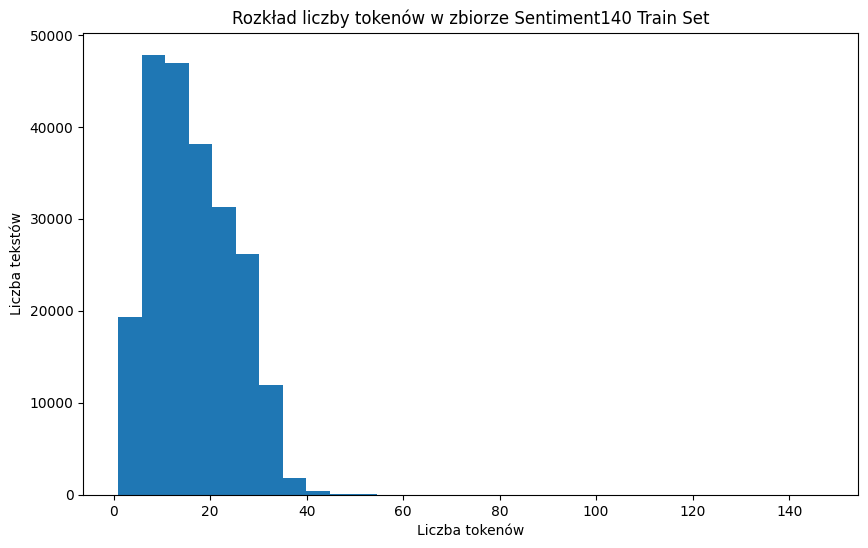

In [59]:
DataUtils.plot_token_distribution(train_sentiment140_df, "Sentiment140 Train Set")

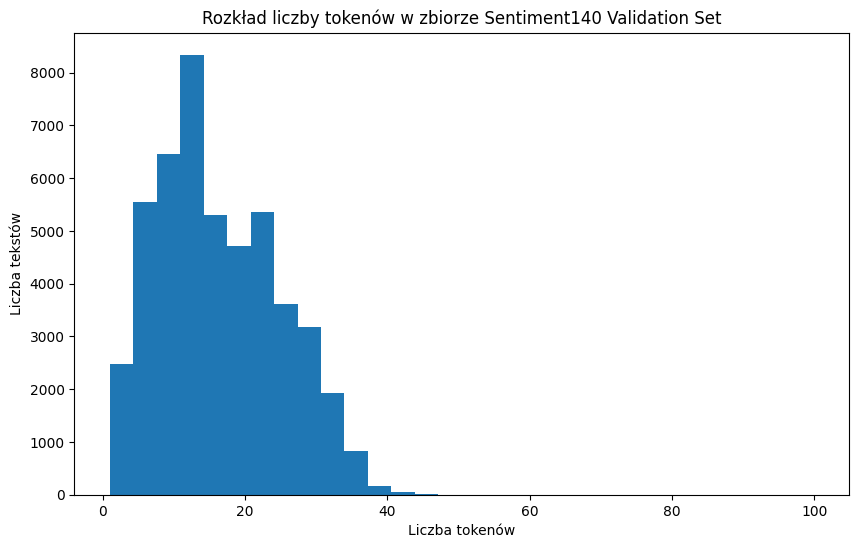

In [60]:
DataUtils.plot_token_distribution(val_sentiment140_df, "Sentiment140 Validation Set")

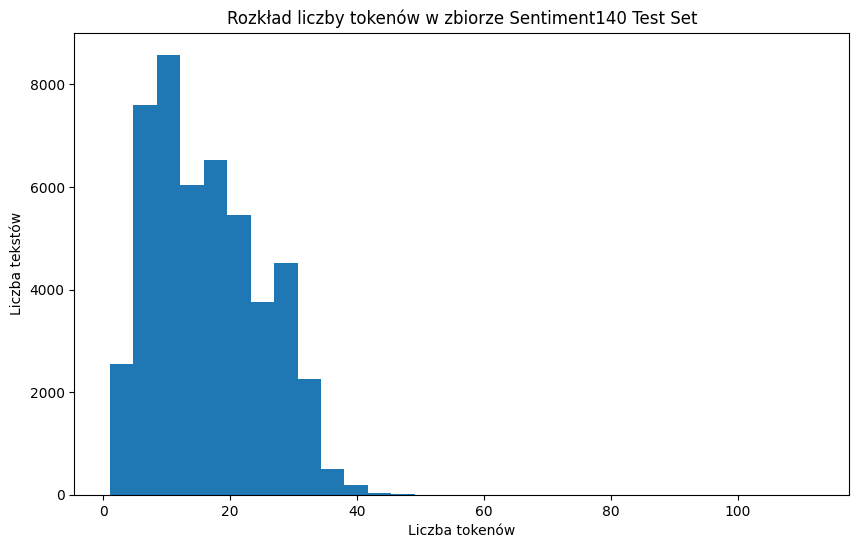

In [61]:
DataUtils.plot_token_distribution(test_sentiment140_df, "Sentiment140 Test Set")

## 2.2. Data Preprocessing

In [62]:
# set preprocessing parameters
vocab_size = 12000  # maximum number of words in the tokenizer
max_length = 64  # maximum length of input sequences

In [63]:
# preprocess train data and fit tokenizer
X_train, y_train, tokenizer = preprocess_data(train_sentiment140_df, max_length=max_length, vocab_size=vocab_size)

In [64]:
# preprocess val data 
X_val, y_val = tokenize_with_existing_tokenizer(val_sentiment140_df, tokenizer, max_length)

In [65]:
# preprocess test data
X_test, y_test = tokenize_with_existing_tokenizer(test_sentiment140_df, tokenizer, max_length)

## 2.3. Model Training

In [66]:
# set model parameters
batch_size = 32
epochs = 10
learning_rate = 0.001

In [67]:
# set embedding parameters
embedding_dim = 300  # dimension of word vectors
embedding_matrix = np.zeros((vocab_size, embedding_dim)) 

for word, i in tokenizer.word_index.items():
    if i < vocab_size:  
        embedding_matrix[i] = fasttext_model.get_word_vector(word)  

print("Embedding matrix created with shape:", embedding_matrix.shape)

Embedding matrix created with shape: (12000, 300)


In [68]:
# define model architecture
model_cnn = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, 
                input_length=max_length, weights=[embedding_matrix], 
                trainable=False),
    Conv1D(filters=256, kernel_size=5, activation='relu', padding='same'),
    GlobalMaxPooling1D(),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])

In [69]:
model_cnn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [70]:
model_cnn.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_3 (Embedding)     (None, 64, 300)           3600000   
                                                                 
 conv1d_7 (Conv1D)           (None, 64, 256)           384256    
                                                                 
 global_max_pooling1d_4 (Glo  (None, 256)              0         
 balMaxPooling1D)                                                
                                                                 
 dense_6 (Dense)             (None, 128)               32896     
                                                                 
 dropout_7 (Dropout)         (None, 128)               0         
                                                                 
 dense_7 (Dense)             (None, 1)                 129       
                                                      

In [71]:
# define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [72]:
# train the model
history_cnn = model_cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping]
)

Epoch 1/10
7000/7000 [==============================] - 129s 18ms/step - loss: 0.4838 - accuracy: 0.7668 - val_loss: 0.4552 - val_accuracy: 0.7836
Epoch 2/10
7000/7000 [==============================] - 119s 17ms/step - loss: 0.4356 - accuracy: 0.7975 - val_loss: 0.4478 - val_accuracy: 0.7923
Epoch 3/10
7000/7000 [==============================] - 121s 17ms/step - loss: 0.4093 - accuracy: 0.8122 - val_loss: 0.4291 - val_accuracy: 0.7989
Epoch 4/10
7000/7000 [==============================] - 117s 17ms/step - loss: 0.3855 - accuracy: 0.8234 - val_loss: 0.4374 - val_accuracy: 0.7982
Epoch 5/10
7000/7000 [==============================] - 119s 17ms/step - loss: 0.3622 - accuracy: 0.8354 - val_loss: 0.4422 - val_accuracy: 0.7953


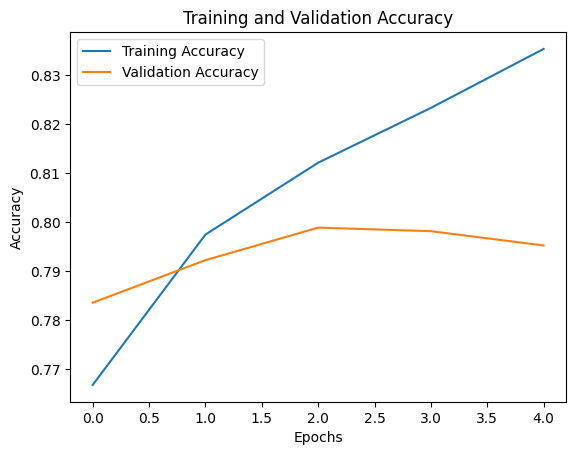

In [73]:
# plot accuracy on training and validation data
plt.plot(history_cnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

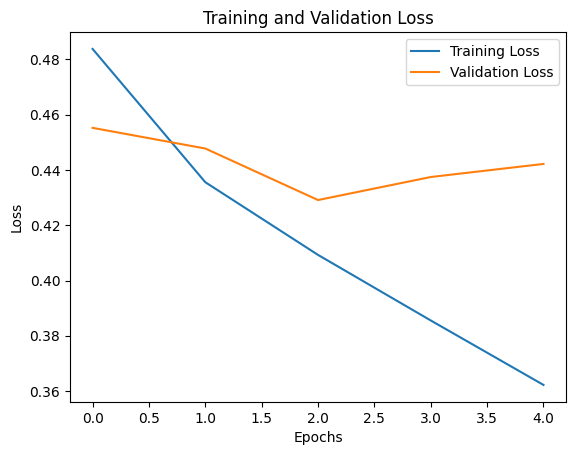

In [74]:
# plot loss on training and validation data
plt.plot(history_cnn.history['loss'], label='Training Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [75]:
# evaluate the model on the validation set
print("\nValidation Results:")
y_val_pred = (model_cnn.predict(X_val) > 0.5).astype(int).flatten()
print(classification_report(y_val, y_val_pred))


Validation Results:
1501/1501 [==============================] - 9s 6ms/step
              precision    recall  f1-score   support

           0       0.79      0.82      0.80     24004
           1       0.81      0.78      0.79     24004

    accuracy                           0.80     48008
   macro avg       0.80      0.80      0.80     48008
weighted avg       0.80      0.80      0.80     48008



## 2.4. Searching for Best Model Parameters

### 2.4.1. BiCNN

In [76]:
def bicnn_sentiment140(vocab_size, learning_rate, embedding_dim, embedding_matrix):
    inputs = Input(shape=(64,))

    embedding = Embedding(input_dim=vocab_size, output_dim=embedding_dim, 
                          input_length=64, weights=[embedding_matrix], 
                          trainable=False)(inputs)

    # forward CNN (left-to-right processing)
    conv_fw = Conv1D(filters=128, kernel_size=3, activation='relu', padding='same')(embedding)
    conv_fw = BatchNormalization()(conv_fw)  
    pool_fw1 = GlobalMaxPooling1D()(conv_fw) 
    pool_fw2 = GlobalAveragePooling1D()(conv_fw) 

    # backward CNN (right-to-left processing)
    reversed_embedding = Lambda(lambda x: tf.reverse(x, axis=[1]))(embedding) 
    conv_bw = Conv1D(filters=128, kernel_size=3, activation='relu', padding='same')(reversed_embedding)
    conv_bw = BatchNormalization()(conv_bw)
    pool_bw1 = GlobalMaxPooling1D()(conv_bw)
    pool_bw2 = GlobalAveragePooling1D()(conv_bw)

    # concatenation of forward and backward features
    concat = Concatenate()([pool_fw1, pool_fw2, pool_bw1, pool_bw2])
    dropout = Dropout(0.5)(concat)  

    # fully connected layer for classification
    dense = Dense(256, activation='relu')(dropout)
    output = Dense(1, activation='sigmoid')(dense)

    model = Model(inputs=inputs, outputs=output)

    model.compile(loss='binary_crossentropy', optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), metrics=['accuracy'])
    
    return model

In [77]:
model_bicnn = bicnn_sentiment140(vocab_size=vocab_size, learning_rate=learning_rate, embedding_dim=embedding_dim, embedding_matrix=embedding_matrix)

In [78]:
model_bicnn.summary()

Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_3 (InputLayer)           [(None, 64)]         0           []                               
                                                                                                  
 embedding_4 (Embedding)        (None, 64, 300)      3600000     ['input_3[0][0]']                
                                                                                                  
 lambda_1 (Lambda)              (None, 64, 300)      0           ['embedding_4[0][0]']            
                                                                                                  
 conv1d_8 (Conv1D)              (None, 64, 128)      115328      ['embedding_4[0][0]']            
                                                                                            

In [79]:
# train the model
history_bicnn = model_bicnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping]
)

Epoch 1/10
7000/7000 [==============================] - 145s 21ms/step - loss: 0.5270 - accuracy: 0.7416 - val_loss: 0.4655 - val_accuracy: 0.7759
Epoch 2/10
7000/7000 [==============================] - 143s 20ms/step - loss: 0.4707 - accuracy: 0.7767 - val_loss: 0.4477 - val_accuracy: 0.7890
Epoch 3/10
7000/7000 [==============================] - 142s 20ms/step - loss: 0.4557 - accuracy: 0.7853 - val_loss: 0.4380 - val_accuracy: 0.7936
Epoch 4/10
7000/7000 [==============================] - 144s 21ms/step - loss: 0.4442 - accuracy: 0.7917 - val_loss: 0.4299 - val_accuracy: 0.8003
Epoch 5/10
7000/7000 [==============================] - 144s 21ms/step - loss: 0.4352 - accuracy: 0.7972 - val_loss: 0.4293 - val_accuracy: 0.7987
Epoch 6/10
7000/7000 [==============================] - 145s 21ms/step - loss: 0.4301 - accuracy: 0.8004 - val_loss: 0.4222 - val_accuracy: 0.8050
Epoch 7/10
7000/7000 [==============================] - 145s 21ms/step - loss: 0.4225 - accuracy: 0.8051 - val_loss: 0

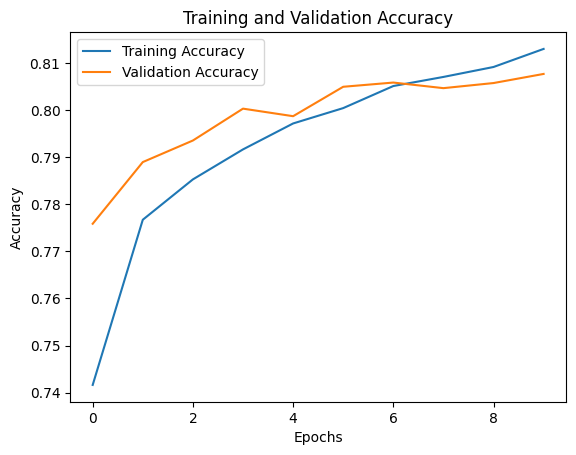

In [80]:
# plot accuracy on training and validation data
plt.plot(history_bicnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_bicnn.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

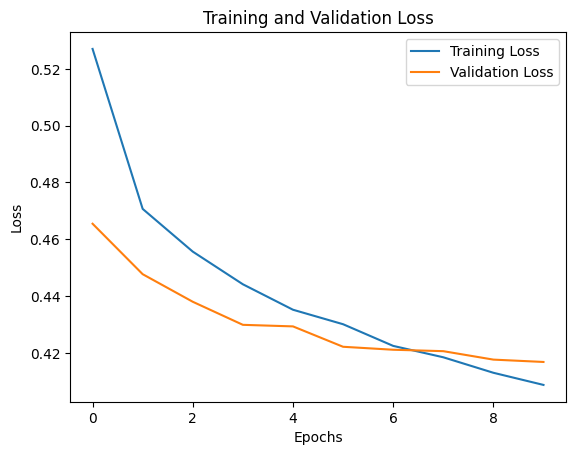

In [81]:
# plot loss on training and validation data
plt.plot(history_bicnn.history['loss'], label='Training Loss')
plt.plot(history_bicnn.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [82]:
# evaluate the model on the validation set
print("\nValidation Results:")
y_val_pred = (model_bicnn.predict(X_val) > 0.5).astype(int).flatten()
print(classification_report(y_val, y_val_pred))


Validation Results:
1501/1501 [==============================] - 11s 7ms/step
              precision    recall  f1-score   support

           0       0.81      0.80      0.81     24004
           1       0.80      0.81      0.81     24004

    accuracy                           0.81     48008
   macro avg       0.81      0.81      0.81     48008
weighted avg       0.81      0.81      0.81     48008



### 2.4.2. TCN (Temporal Convolutional Network) 

In [83]:
def tcn_model_sentiment140(vocab_size, learning_rate, embedding_dim, embedding_matrix, dilation_rates=[1,2,4,8]):
    inputs = Input(shape=(64,))
    
    embedding = Embedding(input_dim=vocab_size, output_dim=embedding_dim, 
                          input_length=64, weights=[embedding_matrix], 
                          trainable=False)(inputs)

    x = embedding # initialize feature extraction pipeline

    # multiple dilated convolutional layers
    for rate in dilation_rates:
        residual = x
        x = Conv1D(filters=embedding_dim, kernel_size=3, activation='relu', padding='same', dilation_rate=rate)(x)
        x = BatchNormalization()(x)
        x = Dropout(0.3)(x)
        x = Add()([x, residual]) 
        x = Activation('relu')(x)

    pool = GlobalMaxPooling1D()(x)

    dense = Dense(256, activation='relu')(pool)

    output = Dense(1, activation='sigmoid')(dense)

    model = Model(inputs=inputs, outputs=output)
    model.compile(loss='binary_crossentropy', optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), metrics=['accuracy'])
    
    return model

In [84]:
model_tcn = tcn_model_sentiment140(vocab_size=vocab_size, learning_rate=learning_rate, embedding_dim=embedding_dim, embedding_matrix=embedding_matrix)

In [85]:
model_tcn.summary()

Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_4 (InputLayer)           [(None, 64)]         0           []                               
                                                                                                  
 embedding_5 (Embedding)        (None, 64, 300)      3600000     ['input_4[0][0]']                
                                                                                                  
 conv1d_10 (Conv1D)             (None, 64, 300)      270300      ['embedding_5[0][0]']            
                                                                                                  
 batch_normalization_8 (BatchNo  (None, 64, 300)     1200        ['conv1d_10[0][0]']              
 rmalization)                                                                               

In [86]:
# train the model
history_tcn = model_tcn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping]
)

Epoch 1/10
7000/7000 [==============================] - 745s 106ms/step - loss: 0.5397 - accuracy: 0.7431 - val_loss: 0.4530 - val_accuracy: 0.7887
Epoch 2/10
7000/7000 [==============================] - 751s 107ms/step - loss: 0.4562 - accuracy: 0.7862 - val_loss: 0.4342 - val_accuracy: 0.7988
Epoch 3/10
7000/7000 [==============================] - 750s 107ms/step - loss: 0.4348 - accuracy: 0.7977 - val_loss: 0.4240 - val_accuracy: 0.8065
Epoch 4/10
7000/7000 [==============================] - 757s 108ms/step - loss: 0.4197 - accuracy: 0.8068 - val_loss: 0.4176 - val_accuracy: 0.8095
Epoch 5/10
7000/7000 [==============================] - 740s 106ms/step - loss: 0.4073 - accuracy: 0.8124 - val_loss: 0.4164 - val_accuracy: 0.8097
Epoch 6/10
7000/7000 [==============================] - 735s 105ms/step - loss: 0.3984 - accuracy: 0.8175 - val_loss: 0.4116 - val_accuracy: 0.8127
Epoch 7/10
7000/7000 [==============================] - 735s 105ms/step - loss: 0.3873 - accuracy: 0.8235 - val_

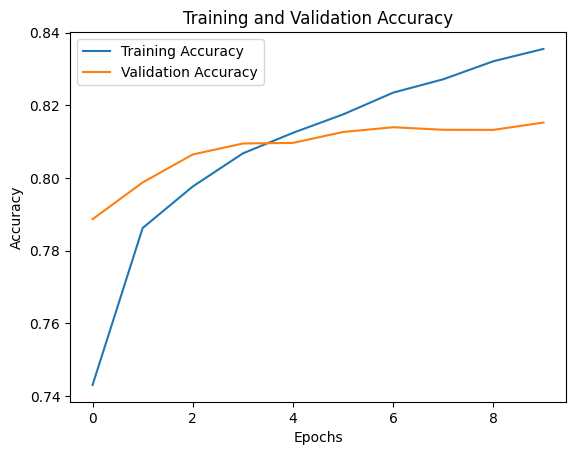

In [87]:
# plot accuracy on training and validation data
plt.plot(history_tcn.history['accuracy'], label='Training Accuracy')
plt.plot(history_tcn.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

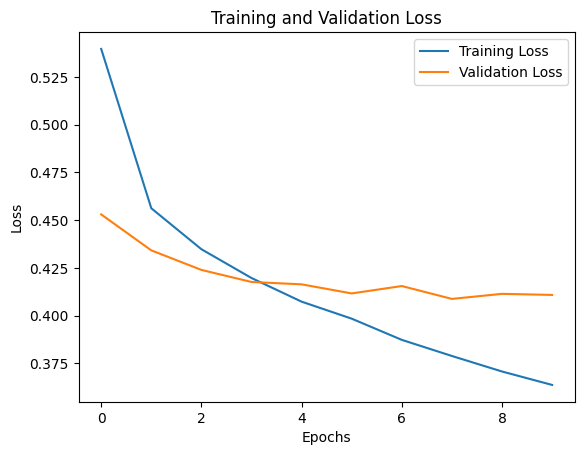

In [88]:
# plot loss on training and validation data
plt.plot(history_tcn.history['loss'], label='Training Loss')
plt.plot(history_tcn.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [89]:
# evaluate the model on the validation set
print("\nValidation Results:")
y_val_pred = (model_tcn.predict(X_val) > 0.5).astype(int).flatten()
print(classification_report(y_val, y_val_pred))


Validation Results:
1501/1501 [==============================] - 37s 25ms/step
              precision    recall  f1-score   support

           0       0.80      0.83      0.82     24004
           1       0.82      0.80      0.81     24004

    accuracy                           0.81     48008
   macro avg       0.81      0.81      0.81     48008
weighted avg       0.81      0.81      0.81     48008



## 2.5. Model Evaluation on Test Data

In [90]:
train_cnn.evaluate_model(model=model_bicnn, tokenizer=tokenizer, test_df=test_sentiment140_df, max_length=max_length)

1500/1500 [==============================] - 11s 7ms/step

Classification Report for Test Set:

              precision    recall  f1-score   support

           0       0.81      0.80      0.81     24000
           1       0.80      0.82      0.81     24000

    accuracy                           0.81     48000
   macro avg       0.81      0.81      0.81     48000
weighted avg       0.81      0.81      0.81     48000



## 2.6. Model Evaluation on Augmented Data

In [91]:
# load the augmented test sets
test_sentiment140_char_swap_file = '../data/preprocessed/sentiment140_test_char_swap.csv'
test_sentiment140_char_swap_df = pd.read_csv(test_sentiment140_char_swap_file, engine='python', encoding="ISO-8859-1")

test_sentiment140_embedding_file = '../data/preprocessed/sentiment140_test_embedding.csv'
test_sentiment140_embedding_df = pd.read_csv(test_sentiment140_embedding_file, engine='python', encoding="ISO-8859-1")

test_sentiment140_eda_file = '../data/preprocessed/sentiment140_test_eda.csv'
test_sentiment140_eda_df = pd.read_csv(test_sentiment140_eda_file, engine='python', encoding="ISO-8859-1")

In [92]:
train_cnn.evaluate_model(model=model_bicnn, tokenizer=tokenizer, test_df=test_sentiment140_char_swap_df, max_length=max_length)

1500/1500 [==============================] - 12s 8ms/step

Classification Report for Test Set:

              precision    recall  f1-score   support

           0       0.80      0.75      0.78     24000
           1       0.77      0.81      0.79     24000

    accuracy                           0.78     48000
   macro avg       0.78      0.78      0.78     48000
weighted avg       0.78      0.78      0.78     48000



In [93]:
train_cnn.evaluate_model(model=model_bicnn, tokenizer=tokenizer, test_df=test_sentiment140_embedding_df, max_length=max_length)


1500/1500 [==============================] - 12s 8ms/step

Classification Report for Test Set:

              precision    recall  f1-score   support

           0       0.80      0.75      0.77     24000
           1       0.77      0.81      0.79     24000

    accuracy                           0.78     48000
   macro avg       0.78      0.78      0.78     48000
weighted avg       0.78      0.78      0.78     48000



In [94]:
train_cnn.evaluate_model(model=model_bicnn, tokenizer=tokenizer, test_df=test_sentiment140_eda_df, max_length=max_length)


1500/1500 [==============================] - 12s 8ms/step

Classification Report for Test Set:

              precision    recall  f1-score   support

           0       0.80      0.77      0.79     24000
           1       0.78      0.81      0.79     24000

    accuracy                           0.79     48000
   macro avg       0.79      0.79      0.79     48000
weighted avg       0.79      0.79      0.79     48000



## 2.7. Save Model

In [95]:
model_path = os.path.join(models_output_dir, "sentiment140_cnn_model.keras")
model_bicnn.save(model_path)

# 3. CNN Model - Yelp Reviews

## 3.1. Loading Data

In [96]:
# load the dataset
yelp_file = '../data/preprocessed/yelp.csv'
yelp_df = pd.read_csv(yelp_file, engine='python', encoding="ISO-8859-1")

In [97]:
# preview the data
yelp_df.head()

,Polarity,Review
0,0,The food was pretty good but the server was so...
1,0,Horrible manager! She told us we only needed t...
2,1,I Love the Black Bean Burger. So much so I cam...
3,0,Off the beaten path and you can either park yo...
4,1,"Awesome NYC pizza, my second favorite NYC styl..."


In [98]:
train_val_yelp_df, test_yelp_df = train_test_split(
    yelp_df, 
    test_size=0.15, 
    random_state=42, 
    stratify=yelp_df['Polarity']
)

In [99]:
train_yelp_df, val_yelp_df = train_test_split(
    train_val_yelp_df, 
    test_size=0.1765, # 15% of the original data
    random_state=42, 
    stratify=train_val_yelp_df['Polarity']
)

In [100]:
DataUtils.count_reviews_by_polarity(train_yelp_df)

Number of reviews with Polarity=1: 39199
Number of reviews with Polarity=0: 39198


In [101]:
DataUtils.count_reviews_by_polarity(val_yelp_df)

Number of reviews with Polarity=1: 8401
Number of reviews with Polarity=0: 8402


In [102]:
DataUtils.count_reviews_by_polarity(test_yelp_df)

Number of reviews with Polarity=1: 8400
Number of reviews with Polarity=0: 8400


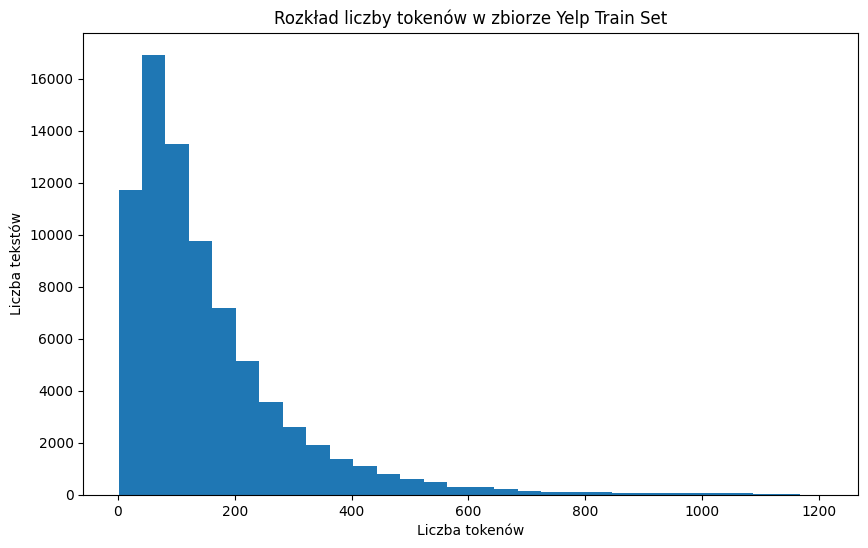

In [103]:
DataUtils.plot_token_distribution(train_yelp_df, "Yelp Train Set")

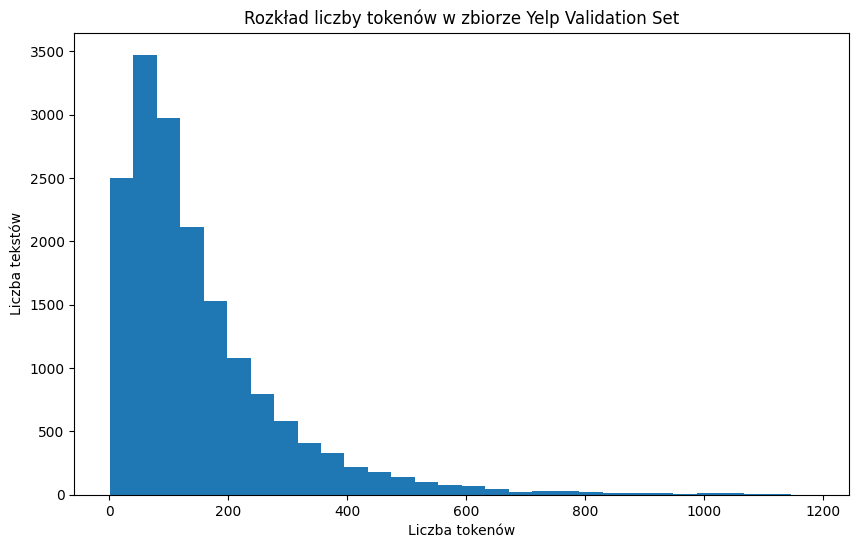

In [104]:
DataUtils.plot_token_distribution(val_yelp_df, "Yelp Validation Set")

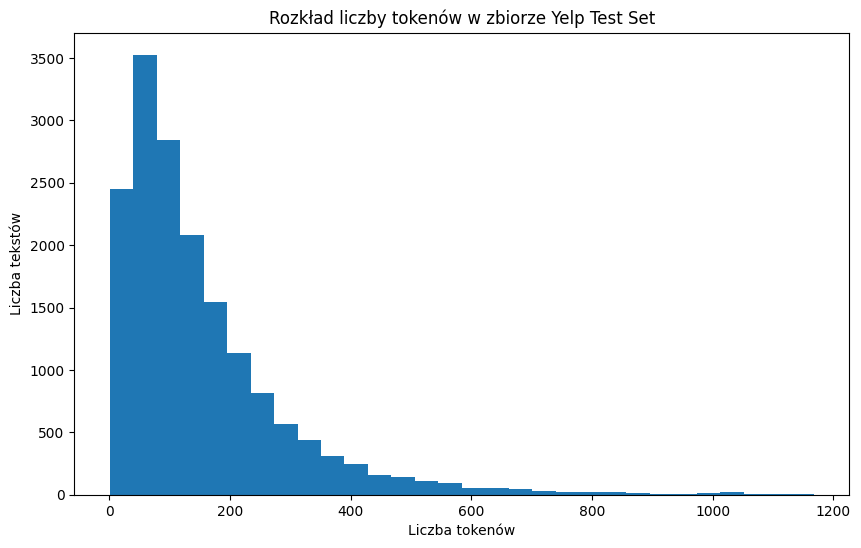

In [105]:
DataUtils.plot_token_distribution(test_yelp_df, "Yelp Test Set")

## 3.2. Data Preprocessing

In [106]:
# set preprocessing parameters
vocab_size = 15000  # maximum number of words in the tokenizer
max_length = 256  # maximum length of input sequences

In [107]:
# preprocess train data and fit tokenizer
X_train, y_train, tokenizer = preprocess_data(train_yelp_df, max_length=max_length, vocab_size=vocab_size)

In [108]:
# preprocess val data 
X_val, y_val = tokenize_with_existing_tokenizer(val_yelp_df, tokenizer, max_length)

In [109]:
# preprocess test data
X_test, y_test = tokenize_with_existing_tokenizer(test_yelp_df, tokenizer, max_length)

## 3.3. Model Training

In [110]:
# set model parameters
batch_size = 32
epochs = 10
learning_rate = 0.001

In [111]:
# set embedding parameters
embedding_dim = 300  # dimension of word vectors
embedding_matrix = np.zeros((vocab_size, embedding_dim)) 

for word, i in tokenizer.word_index.items():
    if i < vocab_size:  
        embedding_matrix[i] = fasttext_model.get_word_vector(word)  

print("Embedding matrix created with shape:", embedding_matrix.shape)

Embedding matrix created with shape: (15000, 300)


In [112]:
# define model architecture
model_cnn = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, 
              input_length=256, weights=[embedding_matrix], trainable=False),
    
    Conv1D(filters=256, kernel_size=5, activation='relu', padding='same'),
    BatchNormalization(),
    
    Conv1D(filters=256, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    
    GlobalMaxPooling1D(),
    
    Dense(256, activation='relu'),
    Dropout(0.4),
    
    Dense(1, activation='sigmoid')
])

In [113]:
model_cnn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [114]:
# define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [115]:
# train the model
history_cnn = model_cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping]
)

Epoch 1/10
2450/2450 [==============================] - 345s 140ms/step - loss: 0.3605 - accuracy: 0.8439 - val_loss: 0.2459 - val_accuracy: 0.8967
Epoch 2/10
2450/2450 [==============================] - 340s 139ms/step - loss: 0.2352 - accuracy: 0.9057 - val_loss: 0.2114 - val_accuracy: 0.9121
Epoch 3/10
2450/2450 [==============================] - 342s 140ms/step - loss: 0.1999 - accuracy: 0.9216 - val_loss: 0.2236 - val_accuracy: 0.9016
Epoch 4/10
2450/2450 [==============================] - 346s 141ms/step - loss: 0.1719 - accuracy: 0.9343 - val_loss: 0.1948 - val_accuracy: 0.9213
Epoch 5/10
2450/2450 [==============================] - 341s 139ms/step - loss: 0.1430 - accuracy: 0.9463 - val_loss: 0.1935 - val_accuracy: 0.9211
Epoch 6/10
2450/2450 [==============================] - 350s 143ms/step - loss: 0.1211 - accuracy: 0.9545 - val_loss: 0.2396 - val_accuracy: 0.9158
Epoch 7/10
2450/2450 [==============================] - 352s 144ms/step - loss: 0.0995 - accuracy: 0.9635 - val_

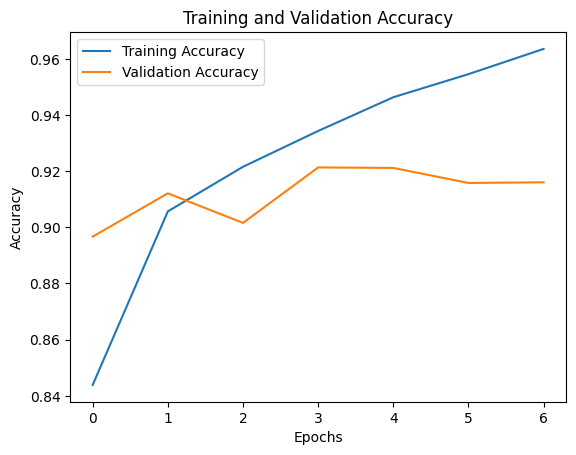

In [116]:
# plot accuracy on training and validation data
plt.plot(history_cnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

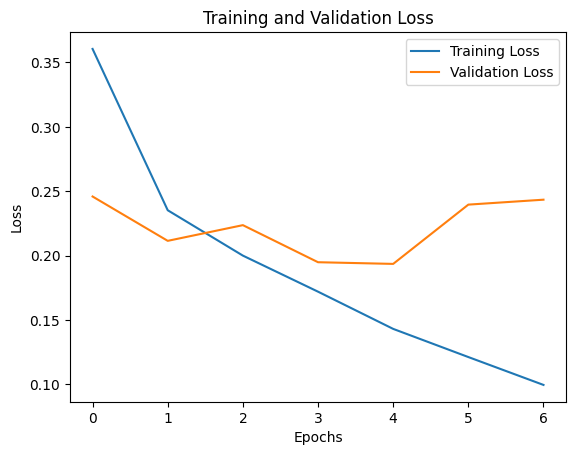

In [117]:
# plot loss on training and validation data
plt.plot(history_cnn.history['loss'], label='Training Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [118]:
# evaluate the model on the validation set
print("\nValidation Results:")
y_val_pred = (model_cnn.predict(X_val) > 0.5).astype(int).flatten()
print(classification_report(y_val, y_val_pred))


Validation Results:
526/526 [==============================] - 14s 27ms/step
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      8402
           1       0.94      0.90      0.92      8401

    accuracy                           0.92     16803
   macro avg       0.92      0.92      0.92     16803
weighted avg       0.92      0.92      0.92     16803



## 3.4. Searching for Best Model Parameters

### 3.4.1. BiCNN

In [119]:
def bicnn_yelp(vocab_size, learning_rate, embedding_dim, embedding_matrix):
    inputs = Input(shape=(256,))

    embedding = Embedding(input_dim=vocab_size, output_dim=embedding_dim, 
                          input_length=256, weights=[embedding_matrix], 
                          trainable=False)(inputs)

    # forward CNN (left-to-right processing)
    conv_fw = Conv1D(filters=128, kernel_size=3, activation='relu', padding='same')(embedding)
    conv_fw = BatchNormalization()(conv_fw)
    conv_fw = Conv1D(filters=128, kernel_size=3, activation='relu', padding='same')(conv_fw)
    conv_fw = BatchNormalization()(conv_fw)
    pool_fw1 = GlobalMaxPooling1D()(conv_fw)
    pool_fw2 = GlobalAveragePooling1D()(conv_fw)

    # reverse input sequence to process right-to-left
    reversed_embedding = Lambda(lambda x: tf.reverse(x, axis=[1]))(embedding)
                              
    # backward CNN (right-to-left processing)
    conv_bw = Conv1D(filters=128, kernel_size=3, activation='relu', padding='same')(reversed_embedding)
    conv_bw = BatchNormalization()(conv_bw)
    conv_bw = Conv1D(filters=128, kernel_size=3, activation='relu', padding='same')(conv_bw)
    conv_bw = BatchNormalization()(conv_bw)
    conv_bw = Dropout(0.3)(conv_bw)
    pool_bw1 = GlobalMaxPooling1D()(conv_bw)
    pool_bw2 = GlobalAveragePooling1D()(conv_bw)

    concat = Concatenate()([pool_fw1, pool_fw2, pool_bw1, pool_bw2])
    dropout = Dropout(0.5)(concat)

    dense = Dense(256, activation='relu')(dropout)
    dense = BatchNormalization()(dense)
    output = Dense(1, activation='sigmoid')(dense)

    model = Model(inputs=inputs, outputs=output)
    model.compile(loss='binary_crossentropy', optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), metrics=['accuracy'])
    
    return model

In [120]:
model_bicnn = bicnn_yelp(vocab_size=vocab_size, learning_rate=learning_rate, embedding_dim=embedding_dim, embedding_matrix=embedding_matrix)

In [121]:
model_bicnn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [122]:
# train the model
history_bicnn = model_bicnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping]
)

Epoch 1/10
2450/2450 [==============================] - 328s 133ms/step - loss: 0.3481 - accuracy: 0.8431 - val_loss: 0.2279 - val_accuracy: 0.9070
Epoch 2/10
2450/2450 [==============================] - 319s 130ms/step - loss: 0.2402 - accuracy: 0.9016 - val_loss: 0.2134 - val_accuracy: 0.9131
Epoch 3/10
2450/2450 [==============================] - 318s 130ms/step - loss: 0.2124 - accuracy: 0.9148 - val_loss: 0.2065 - val_accuracy: 0.9190
Epoch 4/10
2450/2450 [==============================] - 316s 129ms/step - loss: 0.1905 - accuracy: 0.9236 - val_loss: 0.2082 - val_accuracy: 0.9147
Epoch 5/10
2450/2450 [==============================] - 315s 129ms/step - loss: 0.1742 - accuracy: 0.9321 - val_loss: 0.1925 - val_accuracy: 0.9213
Epoch 6/10
2450/2450 [==============================] - 317s 129ms/step - loss: 0.1631 - accuracy: 0.9369 - val_loss: 0.1922 - val_accuracy: 0.9250
Epoch 7/10
2450/2450 [==============================] - 317s 130ms/step - loss: 0.1523 - accuracy: 0.9413 - val_

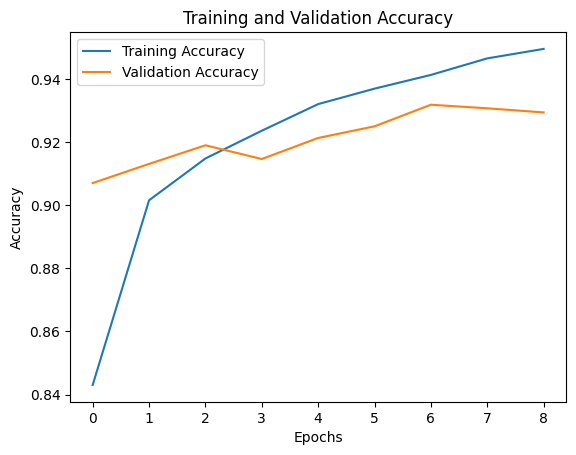

In [123]:
# plot accuracy on training and validation data
plt.plot(history_bicnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_bicnn.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

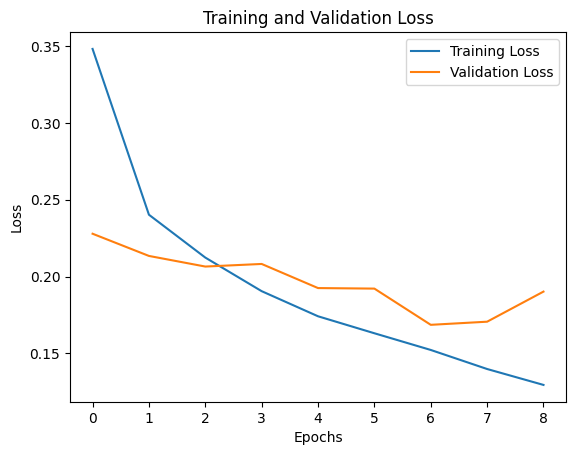

In [124]:
# plot loss on training and validation data
plt.plot(history_bicnn.history['loss'], label='Training Loss')
plt.plot(history_bicnn.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [125]:
# evaluate the model on the validation set
print("\nValidation Results:")
y_val_pred = (model_bicnn.predict(X_val) > 0.5).astype(int).flatten()
print(classification_report(y_val, y_val_pred))


Validation Results:
526/526 [==============================] - 12s 22ms/step
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      8402
           1       0.93      0.93      0.93      8401

    accuracy                           0.93     16803
   macro avg       0.93      0.93      0.93     16803
weighted avg       0.93      0.93      0.93     16803



### 3.4.2. TCN (Temporal Convolutional Network) 

In [126]:
def tcn_model_yelp(vocab_size, learning_rate, embedding_dim, embedding_matrix, dilation_rates=[1,2,4,8]):
    inputs = Input(shape=(256,))
    
    embedding = Embedding(input_dim=vocab_size, output_dim=embedding_dim, 
                          input_length=256, weights=[embedding_matrix], 
                          trainable=False)(inputs)

    x = embedding
    for rate in dilation_rates:
        residual = x
        x = Conv1D(filters=embedding_dim, kernel_size=3, activation='relu', padding='same', dilation_rate=rate)(x)
        x = BatchNormalization()(x)
        x = Dropout(0.3)(x)
        
        residual = Conv1D(filters=128, kernel_size=1, padding='same')(residual) 

        x = Add()([x, residual])  
        x = Activation('relu')(x)


    pool1 = GlobalMaxPooling1D()(x)
    pool2 = GlobalAveragePooling1D()(x)
    concat = Concatenate()([pool1, pool2])

    dense = Dense(256, activation='relu')(concat)
    dropout = Dropout(0.4)(dense)
    output = Dense(1, activation='sigmoid')(dropout)

    model = Model(inputs=inputs, outputs=output)
    model.compile(loss='binary_crossentropy', optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), metrics=['accuracy'])
    
    return model

In [128]:
model_tcn = tcn_model_yelp(vocab_size=vocab_size, embedding_dim=embedding_dim, embedding_matrix=embedding_matrix, learning_rate=learning_rate)

ValueError: Inputs have incompatible shapes. Received shapes (256, 128) and (256, 300)

In [139]:
# train the model
history_tcn = model_tcn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping]
)

Epoch 1/10
2450/2450 [==============================] - 155s 61ms/step - loss: 0.3329 - accuracy: 0.8466 - val_loss: 0.2200 - val_accuracy: 0.9131
Epoch 2/10
2450/2450 [==============================] - 149s 61ms/step - loss: 0.2009 - accuracy: 0.9206 - val_loss: 0.1814 - val_accuracy: 0.9253
Epoch 3/10
2450/2450 [==============================] - 145s 59ms/step - loss: 0.1712 - accuracy: 0.9334 - val_loss: 0.1659 - val_accuracy: 0.9322
Epoch 4/10
2450/2450 [==============================] - 140s 57ms/step - loss: 0.1487 - accuracy: 0.9419 - val_loss: 0.1613 - val_accuracy: 0.9329
Epoch 5/10
2450/2450 [==============================] - 141s 58ms/step - loss: 0.1302 - accuracy: 0.9508 - val_loss: 0.1695 - val_accuracy: 0.9350
Epoch 6/10
2450/2450 [==============================] - 147s 60ms/step - loss: 0.1092 - accuracy: 0.9590 - val_loss: 0.1810 - val_accuracy: 0.9327


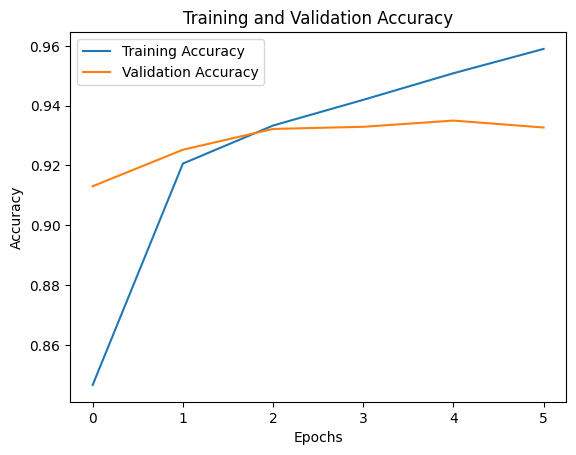

In [140]:
# plot accuracy on training and validation data
plt.plot(history_tcn.history['accuracy'], label='Training Accuracy')
plt.plot(history_tcn.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

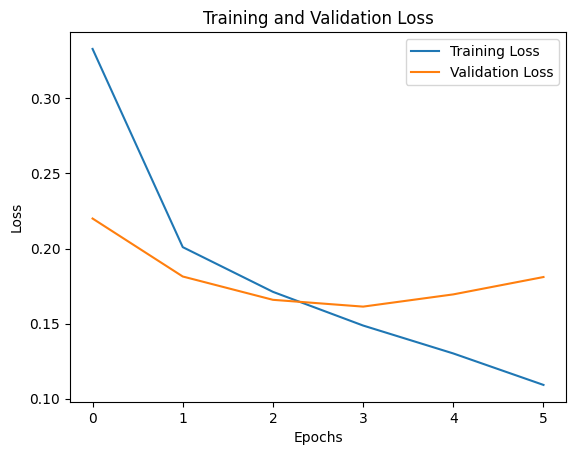

In [141]:
# plot loss on training and validation data
plt.plot(history_tcn.history['loss'], label='Training Loss')
plt.plot(history_tcn.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [142]:
# evaluate the model on the validation set
print("\nValidation Results:")
y_val_pred = (model_tcn.predict(X_val) > 0.5).astype(int).flatten()
print(classification_report(y_val, y_val_pred))


Validation Results:
526/526 [==============================] - 15s 27ms/step
              precision    recall  f1-score   support

           0       0.95      0.92      0.93      8402
           1       0.92      0.95      0.93      8401

    accuracy                           0.93     16803
   macro avg       0.93      0.93      0.93     16803
weighted avg       0.93      0.93      0.93     16803



## 3.5. Model Evaluation on Test Data

In [144]:
train_cnn.evaluate_model(model=model_bicnn, tokenizer=tokenizer, test_df=test_yelp_df, max_length=max_length)

525/525 [==============================] - 14s 27ms/step

Classification Report for Test Set:

              precision    recall  f1-score   support

           0       0.95      0.92      0.93      8400
           1       0.92      0.95      0.94      8400

    accuracy                           0.94     16800
   macro avg       0.94      0.94      0.94     16800
weighted avg       0.94      0.94      0.94     16800



## 3.6. Model Evaluation on Augmented Data

In [145]:
# load the augmented test sets
test_yelp_char_swap_file = '../data/preprocessed/yelp_test_char_swap.csv'
test_yelp_char_swap_df = pd.read_csv(test_yelp_char_swap_file, engine='python', encoding="ISO-8859-1")

test_yelp_transform_file = '../data/preprocessed/yelp_test_transform.csv'
test_yelp_transform_df = pd.read_csv(test_yelp_transform_file, engine='python', encoding="ISO-8859-1")

test_yelp_combined_file = '../data/preprocessed/yelp_test_combined.csv'
test_yelp_combined_df = pd.read_csv(test_yelp_combined_file, engine='python', encoding="ISO-8859-1")

In [146]:
train_cnn.evaluate_model(model=model_bicnn, tokenizer=tokenizer, test_df=test_yelp_char_swap_df, max_length=max_length)

525/525 [==============================] - 13s 24ms/step

Classification Report for Test Set:

              precision    recall  f1-score   support

           0       0.89      0.78      0.84      8400
           1       0.81      0.91      0.85      8400

    accuracy                           0.85     16800
   macro avg       0.85      0.85      0.84     16800
weighted avg       0.85      0.85      0.84     16800



In [147]:
train_cnn.evaluate_model(model=model_bicnn, tokenizer=tokenizer, test_df=test_yelp_transform_df, max_length=max_length)


525/525 [==============================] - 13s 25ms/step

Classification Report for Test Set:

              precision    recall  f1-score   support

           0       0.93      0.90      0.91      8400
           1       0.90      0.93      0.92      8400

    accuracy                           0.91     16800
   macro avg       0.91      0.91      0.91     16800
weighted avg       0.91      0.91      0.91     16800



In [148]:
train_cnn.evaluate_model(model=model_bicnn, tokenizer=tokenizer, test_df=test_yelp_combined_df, max_length=max_length)


525/525 [==============================] - 14s 27ms/step

Classification Report for Test Set:

              precision    recall  f1-score   support

           0       0.87      0.76      0.81      8400
           1       0.78      0.89      0.83      8400

    accuracy                           0.82     16800
   macro avg       0.83      0.82      0.82     16800
weighted avg       0.83      0.82      0.82     16800



## 3.7. Save Model

In [149]:
model_path = os.path.join(models_output_dir, "yelp_cnn_model.keras")
model_bicnn.save(model_path)